# Demographic Trends and Future Demand for Higher Education in Mexico (1990–2040)

This project analyzes demographic trends in Mexico and Nuevo León to understand how population aging may impact the future demand for higher education.

## Business Question

How will demographic changes affect the future pool of university-age students in Mexico and Nuevo León?

## Data Description

The dataset contains population projections from 1990 to 2040, including:

- Total population
- Population by age group (0–14, 15–64, 65+)

Data was processed using SQL and analyzed using Python.

## 1. Import libraries

We start by importing the libraries used for data analysis and visualization.

In [1]:
#Import librarys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load datasets

The analysis uses four datasets previously aggregated in SQL.

- Mexico total population
- Nuevo León total population
- Mexico population by age group
- Nuevo León population by age group

In [2]:
mex = pd.read_csv("mexico_population.csv")
nl = pd.read_csv("NuevoLeon_population.csv")

mex_age = pd.read_csv("Mexico_bygroup_population.csv")
nl_age = pd.read_csv("NuevoLeon_bygroup_population.csv")

## 3. Initial data inspection

Before starting the analysis, we inspect the structure of the datasets.

In [3]:
mex.head()

,ano,poblacion_total,crecimiento
0,1990,84502988,NaN
1,1991,86127477,1.922404
2,1992,87753131,1.887498
3,1993,89364560,1.836321
4,1994,90953505,1.778048


In [4]:
mex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ano              51 non-null     int64  
 1   poblacion_total  51 non-null     int64  
 2   crecimiento      50 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


## 4. Population Growth Trends

This section analyzes how population growth has evolved over time in Mexico and Nuevo León.

### 4.1 Population growth in Mexico

We first analyze the evolution of Mexico's population over time.

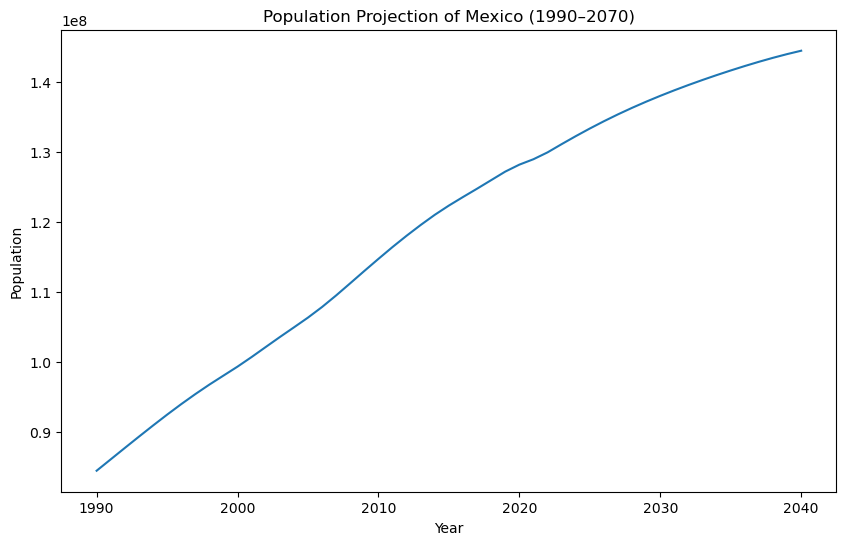

In [5]:
plt.figure(figsize=(10,6))

plt.plot(mex["ano"], mex["poblacion_total"])

plt.title("Population Projection of Mexico (1990–2070)")
plt.xlabel("Year")
plt.ylabel("Population")

plt.show()

### 4.2 Identifying the population peak

An important demographic milestone is the year when the population reaches its maximum.

In [6]:
peak = mex.loc[mex["poblacion_total"].idxmax()]

print(peak)

ano                2.040000e+03
poblacion_total    1.444765e+08
crecimiento        3.359780e-01
Name: 50, dtype: float64


### 4.3 Population growth comparison: Mexico vs Nuevo León

We compare population growth dynamics between the national level and the state of Nuevo León.

In [7]:
mex["decada"] = (mex["ano"] // 10) * 10
nl["decada"] = (nl["ano"] // 10) * 10

In [8]:
mex_decade = mex.groupby("decada")["crecimiento"].mean().reset_index()
nl_decade = nl.groupby("decada")["crecimiento"].mean().reset_index()

In [9]:
decade_table = mex_decade.merge(nl_decade, on="decada", suffixes=("_mex", "_nl"))

In [10]:
decade_table

,decada,crecimiento_mex,crecimiento_nl
0,1990,1.670113,2.030214
1,2000,1.428315,1.942785
2,2010,1.189520,2.199062
3,2020,0.758520,1.635306
4,2030,0.484369,1.220605
5,2040,0.335978,1.017932


In [11]:
df = mex.merge(nl, on="ano", suffixes=("_mex","_nl"))

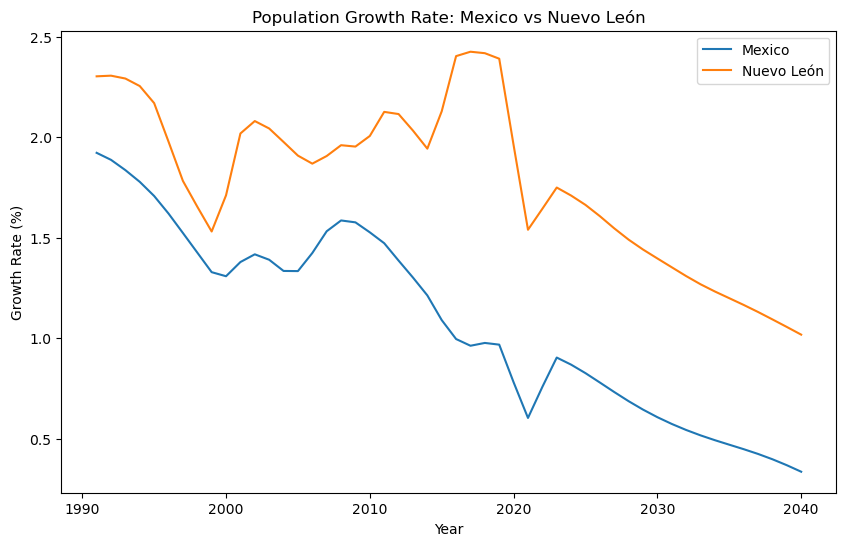

In [12]:
plt.figure(figsize=(10,6))

plt.plot(df["ano"], df["crecimiento_mex"], label="Mexico")
plt.plot(df["ano"], df["crecimiento_nl"], label="Nuevo León")

plt.legend()

plt.title("Population Growth Rate: Mexico vs Nuevo León")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.show()

### Key Insight

Population growth is slowing down in both Mexico and Nuevo León.  
Although Nuevo León has historically grown faster, its growth rate is also declining over time.

## 5. Aging Index (Older Adults per Child)

The aging index measures the number of people aged 65+ relative to those aged 0–14.

In [18]:
mex_age["aging_index"] = mex_age["edad_65_mas"] / mex_age["edad_0_14"]
nl_age["aging_index"] = nl_age["edad_65_mas"] / nl_age["edad_0_14"]

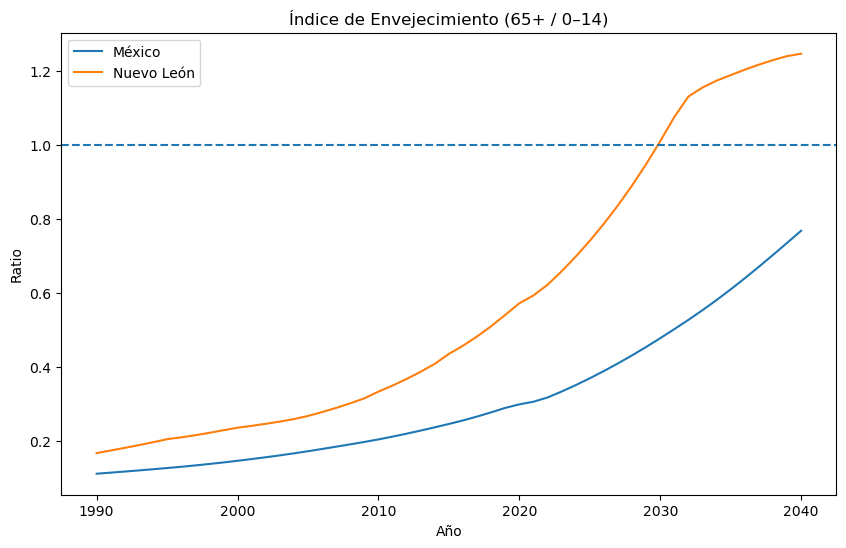

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(mex_age["ano"], mex_age["aging_index"], label="México")
plt.plot(nl_age["ano"], nl_age["aging_index"], label="Nuevo León")

plt.axhline(1, linestyle="--")

plt.title("Índice de Envejecimiento (65+ / 0–14)")
plt.xlabel("Año")
plt.ylabel("Ratio")
plt.legend()

plt.show()

### Key Insight

Nuevo León is aging faster than the national average.  
The ratio of older adults to children is increasing more rapidly, indicating an accelerated demographic transition.

## 6. Population structure in Mexico vs Nuevo León

Population by age group helps us understand demographic transition and aging patterns.

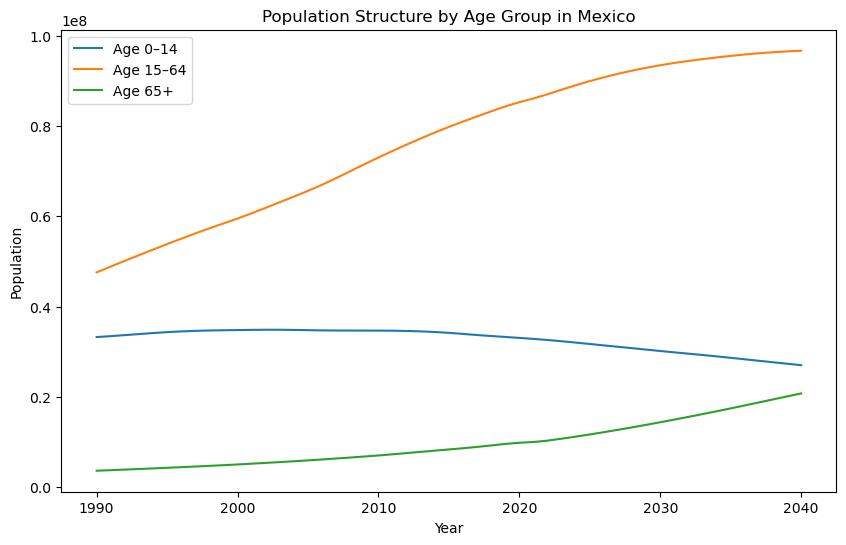

In [14]:
plt.figure(figsize=(10,6))

plt.plot(mex_age["ano"], mex_age["edad_0_14"], label="Age 0–14")
plt.plot(mex_age["ano"], mex_age["edad_15_64"], label="Age 15–64")
plt.plot(mex_age["ano"], mex_age["edad_65_mas"], label="Age 65+")

plt.legend()

plt.title("Population Structure by Age Group in Mexico")
plt.xlabel("Year")
plt.ylabel("Population")

plt.show()

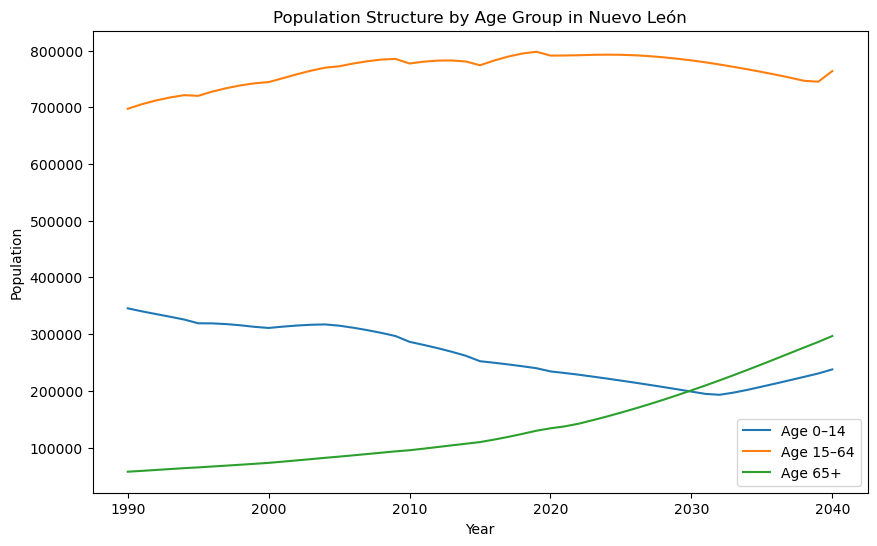

In [15]:
plt.figure(figsize=(10,6))

plt.plot(nl_age["ano"], nl_age["edad_0_14"], label="Age 0–14")
plt.plot(nl_age["ano"], nl_age["edad_15_64"], label="Age 15–64")
plt.plot(nl_age["ano"], nl_age["edad_65_mas"], label="Age 65+")

plt.legend()

plt.title("Population Structure by Age Group in Nuevo León")
plt.xlabel("Year")
plt.ylabel("Population")

plt.show()

### Key Insight

The young population (0–14) is declining, while the elderly population (65+) is growing significantly.  
In Nuevo León, older adults are projected to surpass the young population earlier than in Mexico.

## Conclusion

The analysis reveals a clear demographic transition in both Mexico and Nuevo León, characterized by slowing population growth, declining younger cohorts, and a rapid increase in the elderly population.

While these trends are present at the national level, Nuevo León shows a faster pace of aging. The aging index indicates that the proportion of older adults relative to children is increasing more rapidly, suggesting that the demographic shift will occur earlier in the state than in the country as a whole.

These changes imply a potential reduction in the future pool of university-age students, particularly in Nuevo León. As a result, higher education institutions may need to adapt their strategies by diversifying their target audience, expanding lifelong learning programs, and rethinking traditional enrollment models.

Overall, demographic trends suggest that future demand for higher education will be shaped not only by population size, but by significant shifts in age structure.